# Testing file 

The purpose of this Jupyter Note Book file is to simply test all the functions that we propose in this project. 

## Testing opening.py

### Test the effective work

We recall that this file is made to open the specific type of excel file mentionned in README. Let's first try to import Test_1_pollen.xlsx. 

In [1]:
from opening import gen_data, extract

import pandas as pd
import numpy as np
import pathlib as Path

Let's see what type of Data Frame we obtain. Normally, it should contain : 
- 1st line : a series of numbers representing the layer depth
- Other lines : the 1st cell shoule be a name, the other ones numbers

In [2]:
data_1 =  extract("./excel/Test_1_pollen.xlsx")
print("The type of data_1 is : ", type(data_1))

The excel file treated by pandas is : 
                        0    1    2    3    4    5    6    7    8    9    10
0                      NaN    1    4    5    7    9   11   13   15   17   18
1                  _ABIES,    1    1    0    0    5    2    0    0    0    0
2                 _CEDRUS,    0    2    0    0    0    2    4    0    1    0
3              _JUNIPERUS,    1    4    1    4    5    4    0   10    2    4
4                  _PICEA,    1    1    0    1    0    0    0    0    0    0
5                  _PINUS,  118  190  152  239  198  255  167  169  149  208
6   _EPHEDRA DISTACHYA t.,    0    0    0    0    0    0    0    0    1    0
7    _EPHEDRA FRAGILIS t.,    0    1    0    0    2    0    0    0    0    0
8                  _ALNUS,    4    5    4    2    7    6    4   11    4    2
9                  _SALIX,    0    1    1    0    0    0    2    1    3    1
10               _TAMARIX,    0    1    1    0    0    1    0    0    0    0
11                _BETULA,    6    3 

In fact, we find the wanted structure as a pandas Data Frame. 

We can now extract correctly the data into : 
- a Numpy array : for layer depth
- a dictionnary : for pollen quantities


In [3]:
gen_data(data_1)

For the data Test_1, we obtain the following depth array :  [ 1.  4.  5.  7.  9. 11. 13. 15. 17. 18.]
It contains 10 layers.

The taxa studied in Test_1 are the following : ['_ABIES,' '_CEDRUS,' '_JUNIPERUS,' '_PICEA,' '_PINUS,'
 '_EPHEDRA DISTACHYA t.,' '_EPHEDRA FRAGILIS t.,' '_ALNUS,' '_SALIX,'
 '_TAMARIX,' '_BETULA,' '_OSTRYA,']

We obtain the following dictionnary for Test_1 data :  {'_ABIES,': array([1., 1., 0., 0., 5., 2., 0., 0., 0., 0.]), '_CEDRUS,': array([0., 2., 0., 0., 0., 2., 4., 0., 1., 0.]), '_JUNIPERUS,': array([ 1.,  4.,  1.,  4.,  5.,  4.,  0., 10.,  2.,  4.]), '_PICEA,': array([1., 1., 0., 1., 0., 0., 0., 0., 0., 0.]), '_PINUS,': array([118., 190., 152., 239., 198., 255., 167., 169., 149., 208.]), '_EPHEDRA DISTACHYA t.,': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]), '_EPHEDRA FRAGILIS t.,': array([0., 1., 0., 0., 2., 0., 0., 0., 0., 0.]), '_ALNUS,': array([ 4.,  5.,  4.,  2.,  7.,  6.,  4., 11.,  4.,  2.]), '_SALIX,': array([0., 1., 1., 0., 0., 0., 2., 1., 3., 

({'_ABIES,': array([1., 1., 0., 0., 5., 2., 0., 0., 0., 0.]),
  '_CEDRUS,': array([0., 2., 0., 0., 0., 2., 4., 0., 1., 0.]),
  '_JUNIPERUS,': array([ 1.,  4.,  1.,  4.,  5.,  4.,  0., 10.,  2.,  4.]),
  '_PICEA,': array([1., 1., 0., 1., 0., 0., 0., 0., 0., 0.]),
  '_PINUS,': array([118., 190., 152., 239., 198., 255., 167., 169., 149., 208.]),
  '_EPHEDRA DISTACHYA t.,': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
  '_EPHEDRA FRAGILIS t.,': array([0., 1., 0., 0., 2., 0., 0., 0., 0., 0.]),
  '_ALNUS,': array([ 4.,  5.,  4.,  2.,  7.,  6.,  4., 11.,  4.,  2.]),
  '_SALIX,': array([0., 1., 1., 0., 0., 0., 2., 1., 3., 1.]),
  '_TAMARIX,': array([0., 1., 1., 0., 0., 1., 0., 0., 0., 0.]),
  '_BETULA,': array([6., 3., 5., 4., 2., 4., 1., 5., 2., 3.])},
 array([ 1.,  4.,  5.,  7.,  9., 11., 13., 15., 17., 18.]))

As wanted, we obtain the equivalent of our Excel file into a ordered dictionnary. To each taxa-key, we have a numpy array of the number of pollen found for each layer. 

### Test of the errors 

In each function, we integrated purposely raising errors to prevent some forms of wrong arguments and to avert 

- If we do not have an Excel file : 

In [4]:
data_1_error_txt = extract("./excel/Test_1_error.txt")

AssertionError: The extension do not seem to be the one of an Excel file

- If we have an Excel file but not structured as wanted : 

In [ ]:
data_1_error_xlsx = extract("./excel/Test_1_error.xlsx")

The excel file treated by pandas is : 
      0     1         2       3     4
0  This  file  contains  wrong   data
1     1     2         3       4     5
2     6     7         8       9    10
3    11    12        13      14    15



The extraction is correct but the data is not structured as wanted, so : 

In [ ]:
gen_data(data_1_error_xlsx)

ValueError: could not convert string to float: 'file'

In [ ]:
gen_data("./excel/Test_1_error.xlsx")

AssertionError: ./excel/Test_1_error.xlsx is not a Data Frame. Check gen_data argument.

## Testing pollinic.py

Now we want to test the good implementation of the pollinic diagrams. 

### Test the effective 

To proceed, we will first use a simple core where we found 2 taxa and composed of only 4 layers. 

In [5]:
from pollinic import percentage, pollinic_diag

In [6]:
data_simple = {'Taxa_1' : [1, 4, 5, 2],  'Taxa_2' : [6, 2, 5, 1]}
depth_simple = np.array([1, 3, 6, 8])

Let's first test the function percentage : we will check the good argument in the list. 

In [7]:
percent_data_simple = percentage(data_simple, depth_simple)
print(percent_data_simple)

{'Taxa_1': [0.14285714285714285, 0.6666666666666666, 0.5, 0.6666666666666666], 'Taxa_2': [0.8571428571428571, 0.3333333333333333, 0.5, 0.3333333333333333]}


Let's check that the sum over each layer is correctly equal to 1. 

In [8]:
for i in range(len(percent_data_simple['Taxa_1'])): 
    total = 0 
    for key in data_simple:
        total += data_simple[key][i] 
    print(f"For the layer {i}, we have a total value of {total}")

For the layer 0, we have a total value of 1.0
For the layer 1, we have a total value of 1.0
For the layer 2, we have a total value of 1.0
For the layer 3, we have a total value of 1.0


Now let's test the function pollinic_diag. We want to make sure that the data is : 
- readable 
- correct
- coherent in the printing, meaning that space is not occupied randomly and excessively

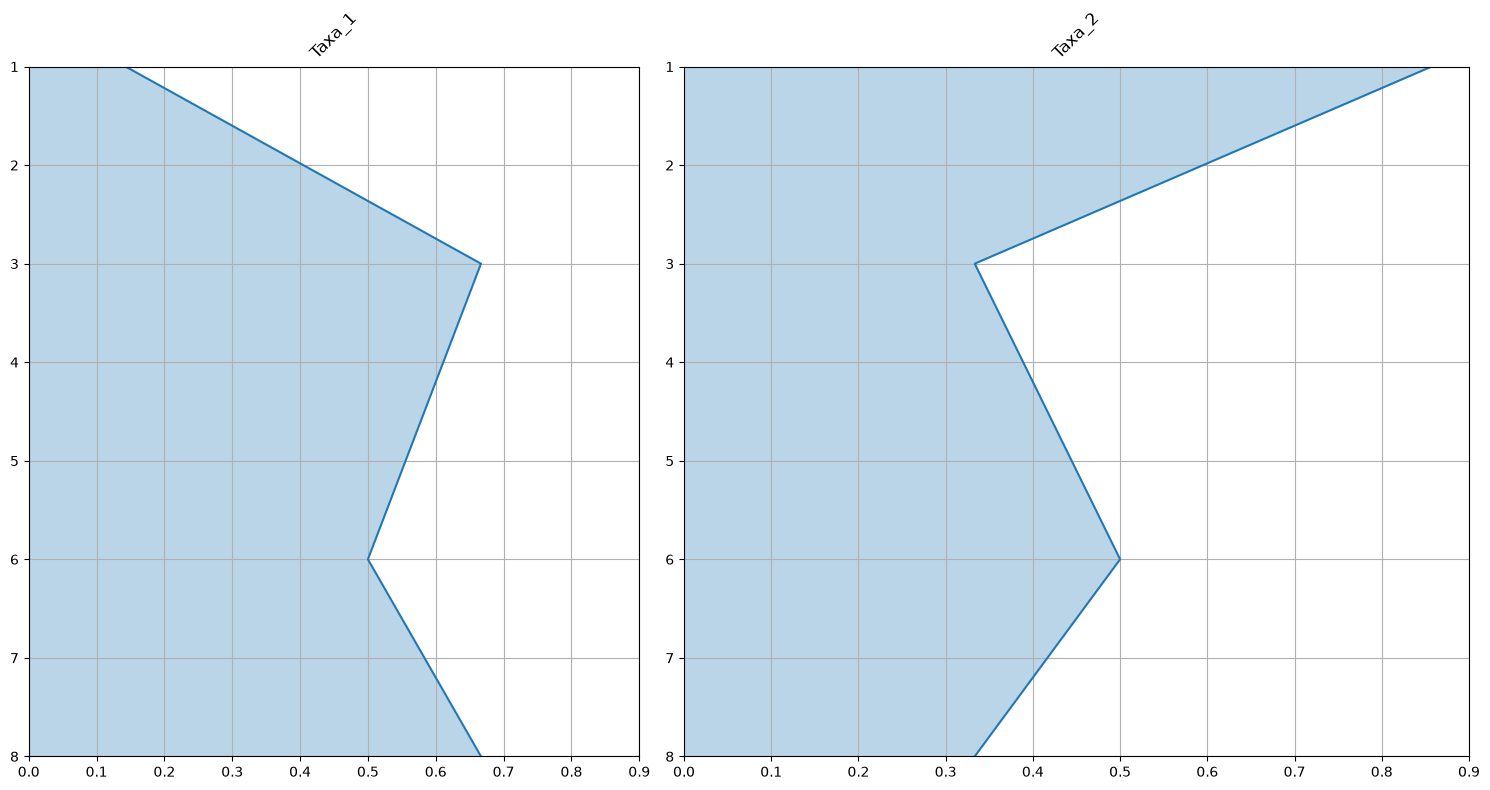

In [9]:
pollinic_diag(percent_data_simple, depth_simple)

Let's try to display more data. 
To do so, we will generate randomly a test dictionnary of 20 taxa of 30 layers :

In [10]:
data_complex = {}
for i in range(20): 
    table = np.random.randint(0, 400, size = 30).astype(float)
    data_complex[f'Taxa_{i}'] = table

depth_complex = np.random.choice(np.arange(1, 101), size = 30, replace=False)
depth_complex = np.sort(depth_complex)

print(data_complex)
print()
print(depth_complex)

{'Taxa_0': array([ 68.,  30., 383., 172., 331., 280.,   3.,  61., 276., 169., 312.,
       312., 246., 109., 384., 241.,  93.,  35., 145., 106., 355., 304.,
        78., 286.,  88., 103., 169., 167., 208.,  13.]), 'Taxa_1': array([369., 350., 369., 175., 152., 254., 136., 205.,  26., 136.,  47.,
       327., 386., 220.,  98., 344., 161.,  43., 378., 252., 157., 276.,
       124., 378., 206., 225.,  39., 123., 308., 116.]), 'Taxa_2': array([134., 298., 158., 183., 375., 126., 392., 249., 156., 241., 177.,
       184., 146., 130., 248., 321., 306.,  31.,   6., 226., 189.,  97.,
        28., 110., 272., 247.,  56., 151., 242.,  65.]), 'Taxa_3': array([ 74., 172., 113., 347., 310., 303., 240., 360., 304.,  22., 291.,
        25., 201., 261., 301.,  93.,  61.,  72., 265., 301., 336.,  98.,
       320., 245.,  72.,  53., 183., 301., 296.,  98.]), 'Taxa_4': array([  2., 116.,  17.,  65., 314.,  64., 145., 255., 156., 377., 310.,
       135.,  63.,  59., 265., 135., 174.,  46., 302.,  98., 382

Testing the printing : 

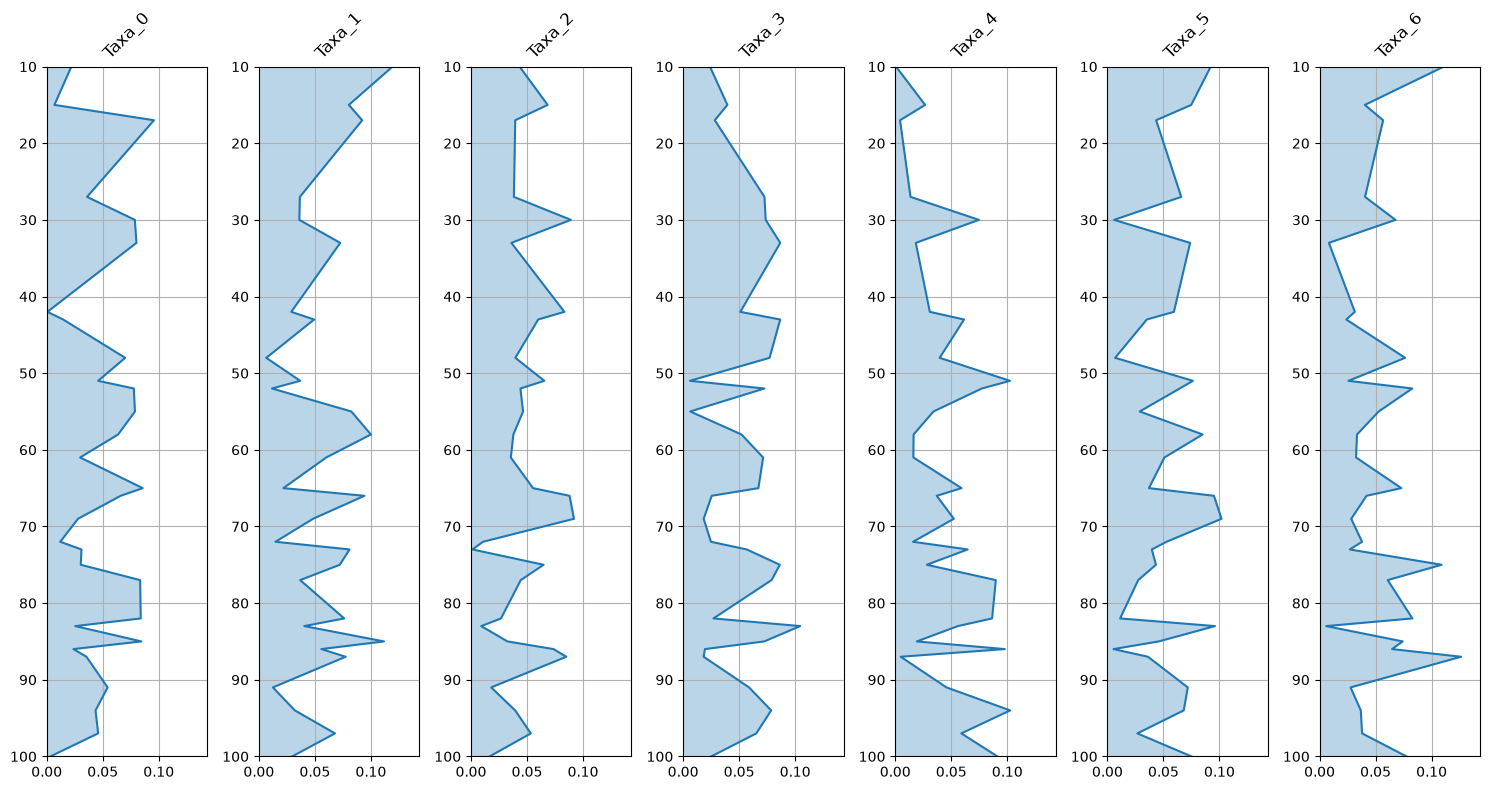

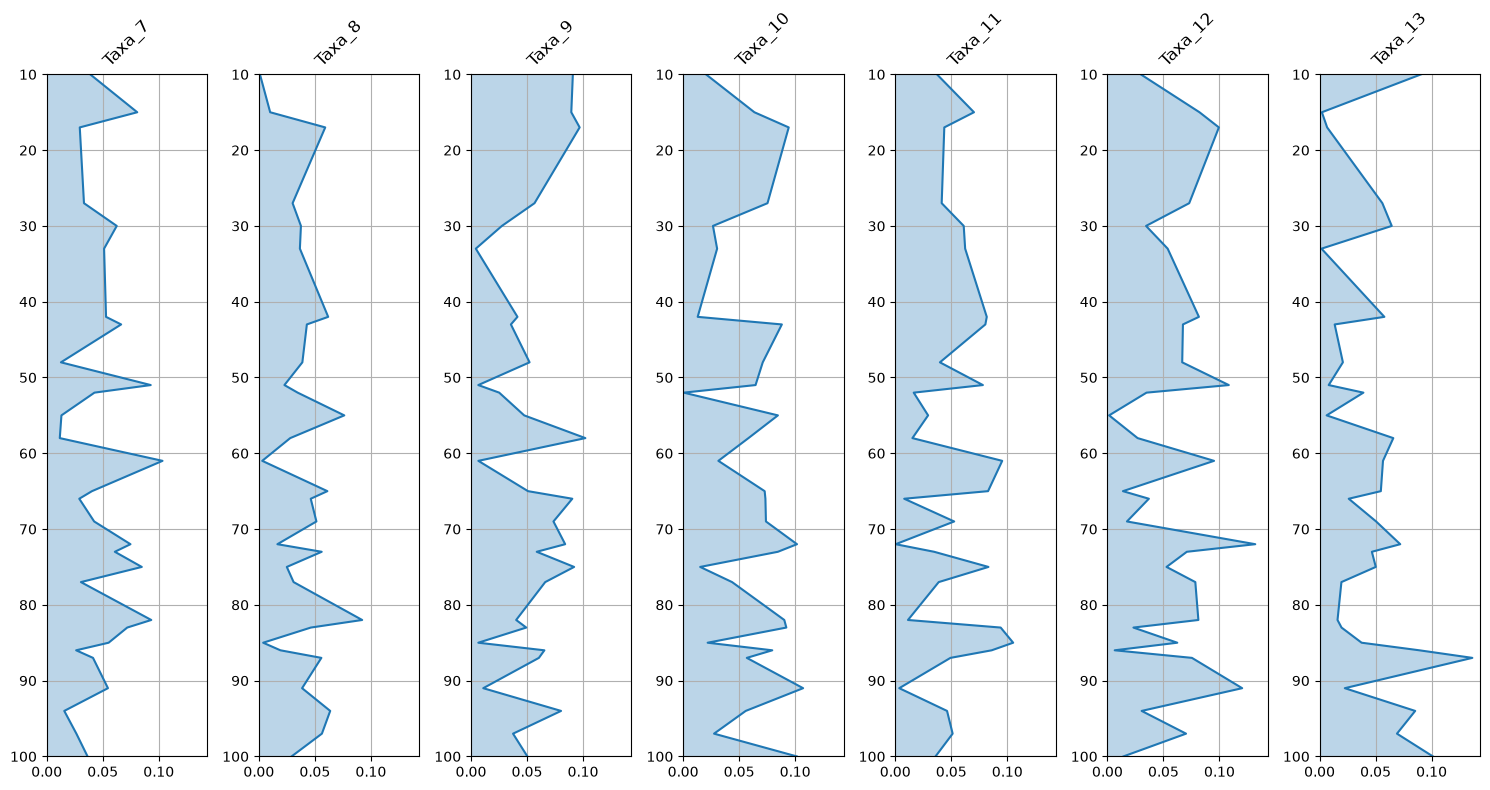

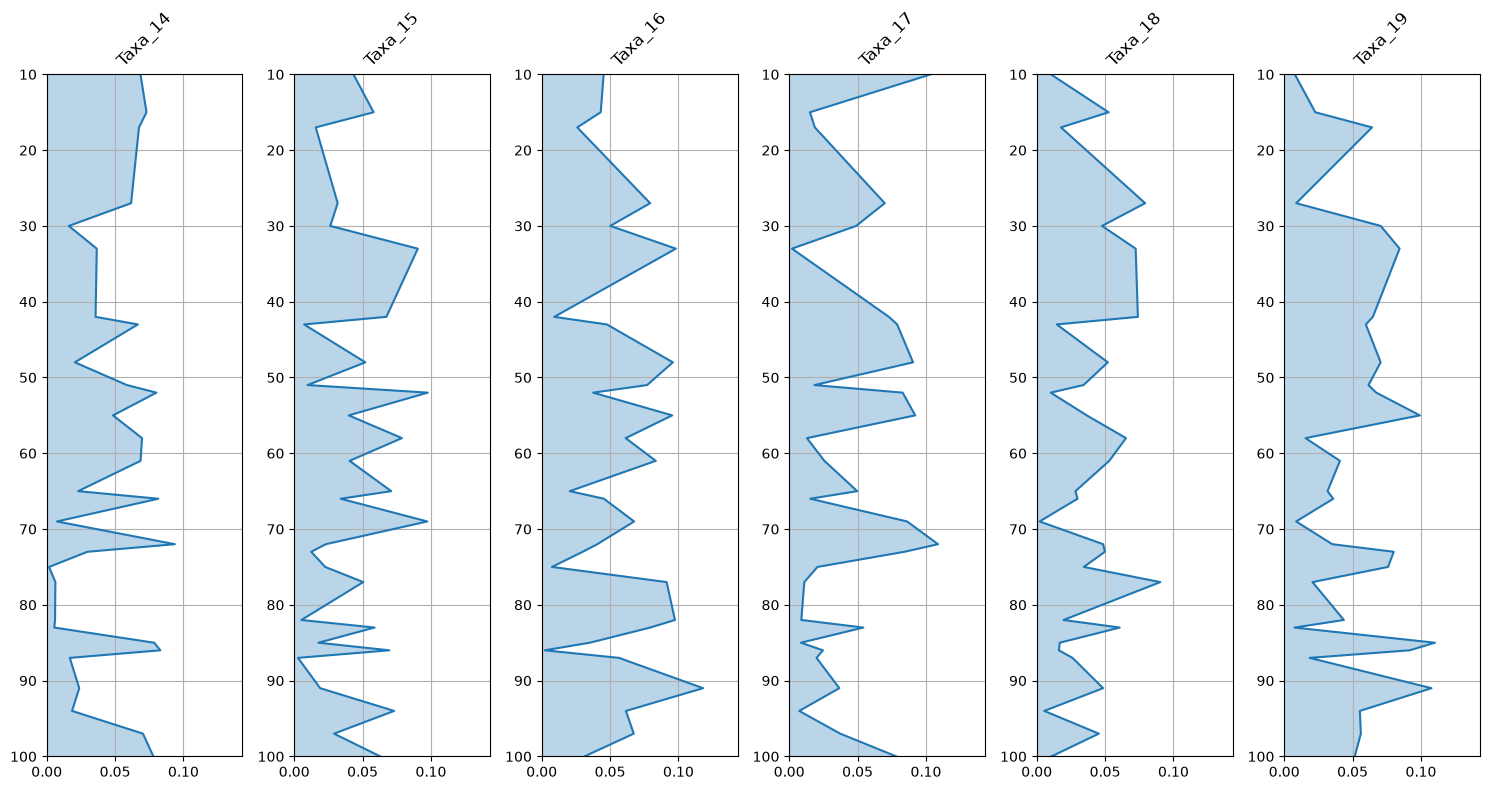

In [11]:
percent_data_complex = percentage(data_complex, depth_complex)
pollinic_diag(percent_data_complex, depth_complex)

In [12]:
percent_data_real_brut =  extract("./excel/Thau_Lagoon_psimpoll.xlsx")
percent_data_real, depth_real = gen_data(percent_data_real_brut)

pollinic_diag(percent_data_real, depth_real)

The excel file treated by pandas is : 
                          0      1      2      3      4      5      6      7   \
0               Sample depth    1.0    4.0    5.0    7.0    9.0   11.0   13.0   
1                 Pollen sum  277.0  437.0  344.0  515.0  517.0  567.0  382.0   
2                 No of taxa   25.0   35.0   23.0   30.0   31.0   34.0   26.0   
3                    _ABIES,    1.0    1.0    NaN    NaN    5.0    2.0    NaN   
4                   _CEDRUS,    NaN    2.0    NaN    NaN    NaN    2.0    4.0   
..                       ...    ...    ...    ...    ...    ...    ...    ...   
106                 _GLOMUS,    NaN    NaN    NaN    NaN    NaN    1.0    NaN   
107           _SORDARIA t.,     NaN    NaN    NaN    NaN    NaN    NaN    NaN   
108        _USTULINA DEUSTA,    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
109  _foraminiferal linings,    1.0    NaN    3.0    2.0    1.0    6.0    4.0   
110              _TRICHURIS,    NaN    NaN    NaN    1.0    NaN    NaN

ValueError: Number of columns must be a positive integer, not 0

<Figure size 1500x800 with 0 Axes>